In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- PART 1: DETECTION & SAVING ---

# Load YOLOv4
net = cv2.dnn.readNet("yolov4.weights", "yolov4.cfg")
with open("coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers().flatten()]

cap = cv2.VideoCapture(0)
print("Webcam started. 1) Click the video window. 2) Press 's' to save. 3) Press 'q' to quit.")

filename = "captured_image.png"

try:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
            
        height, width, _ = frame.shape
        blob = cv2.dnn.blobFromImage(frame, 1/255.0, (416, 416), swapRB=True, crop=False)
        net.setInput(blob)
        outputs = net.forward(output_layers)

        boxes, confidences, class_ids = [], [], []
        for output in outputs:
            for detection in output:
                scores = detection[5:]
                class_id = np.argmax(scores)
                if scores[class_id] > 0.5:
                    w, h = int(detection[2] * width), int(detection[3] * height)
                    x, y = int((detection[0] * width) - w / 2), int((detection[1] * height) - h / 2)
                    boxes.append([x, y, w, h])
                    confidences.append(float(scores[class_id]))
                    class_ids.append(class_id)

        indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
        if len(indices) > 0:
            for i in indices.flatten():
                x, y, w, h = boxes[i]
                cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.putText(frame, classes[class_ids[i]], (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        cv2.imshow("YOLO Detection", frame)
        
        # Capture keys
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            print("Closing...")
            break
        elif key == ord('s'):
            cv2.imwrite(filename, frame)
            print(f"✅ Success! Saved as {filename}")

finally:
    cap.release()
    cv2.destroyAllWindows()
    # Forces windows to close in some IDEs
    for i in range(4): cv2.waitKey(1)


Webcam started. 1) Click the video window. 2) Press 's' to save. 3) Press 'q' to quit.
✅ Success! Saved as captured_image.png
✅ Success! Saved as captured_image.png
Closing...



Displaying saved result:


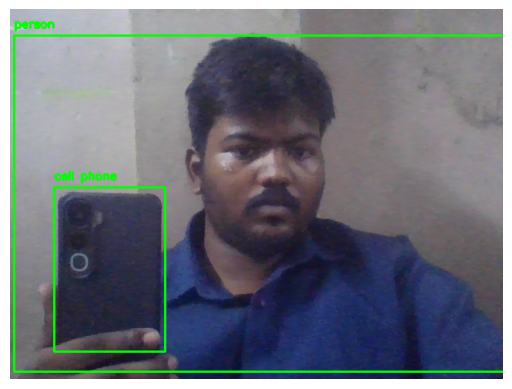

In [8]:
# 8. Display the saved image
if os.path.exists(filename):
    print("\nDisplaying saved result:")
    img = cv2.imread(filename)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print("\n❌ No image saved. You must press 's' while the webcam is running.")